# Exploración de Datos Agro-Satelitales para Modelado de Rendimiento en Viñedos

**TFM — Análisis de productividad de viñedos**

Este notebook explora las dos fuentes de datos del proyecto:
1. **Datos agrícolas** procesados del preprocesado (`vinedos_modelo_limpio.csv`)
2. **Sistema de imágenes satelitales** (Agrixel-FAIR: S1, S2, S3, MODIS, ERA5)

**Objetivos**:
- Análisis exploratorio completo del dataset agrícola
- Análisis de las geometrías AOI y su enlace con datos de producción
- Inventario del estado actual de datos satelitales
- Propuesta de features satelitales para modelado de `yield_kg_ha`
- Prototipo del dataset consolidado agro-satélite

## 0. Configuración y dependencias

In [1]:
import re
import json
import unicodedata
import warnings
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterio.mask
import seaborn as sns
import xarray as xr
from pyproj import Transformer
from scipy import stats
from shapely import wkt
from shapely.geometry import mapping
from shapely.ops import transform

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})
sns.set_style("whitegrid")

print("✓ Dependencias cargadas")

✓ Dependencias cargadas


In [2]:
# --- Rutas del proyecto ---
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
AGRIXEL_DIR = ROOT / "agrixel-fair-dockerV2"
AOI_CSV = AGRIXEL_DIR / "data" / "input" / "aoi_table.csv"
SAT_OUTPUT = AGRIXEL_DIR / "data" / "output" / "files"

# Verificar archivos críticos
archivos = {
    "Dataset agrícola": PROCESSED_DIR / "vinedos_modelo_limpio.csv",
    "Diccionario": PROCESSED_DIR / "vinedos_modelo_diccionario.csv",
    "AOI table": AOI_CSV,
    "Full AOI table": RAW_DIR / "Full_aoi_table.xlsx",
    "Satelital output": SAT_OUTPUT,
}
for nombre, ruta in archivos.items():
    existe = "✓" if ruta.exists() else "✗"
    print(f"  {existe} {nombre}: {ruta.relative_to(ROOT)}")

  ✓ Dataset agrícola: data/processed/vinedos_modelo_limpio.csv
  ✓ Diccionario: data/processed/vinedos_modelo_diccionario.csv
  ✓ AOI table: agrixel-fair-dockerV2/data/input/aoi_table.csv
  ✓ Full AOI table: data/raw/Full_aoi_table.xlsx
  ✓ Satelital output: agrixel-fair-dockerV2/data/output/files


In [3]:
# --- Funciones reutilizables del preprocesado ---
def normalize_col(col: str) -> str:
    col = str(col).strip().lower()
    col = unicodedata.normalize("NFKD", col).encode("ascii", "ignore").decode("ascii")
    col = re.sub(r"[^a-z0-9]+", "_", col)
    return re.sub(r"_+", "_", col).strip("_")

def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [normalize_col(c) for c in df.columns]
    return df

def split_ids(value) -> list[str]:
    if pd.isna(value):
        return []
    return [v.strip() for v in str(value).split(",") if v.strip()]

# --- Reproyección ---
_t3857_4326 = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

def reproject_to_4326(geom):
    return transform(_t3857_4326.transform, geom)

print("✓ Funciones auxiliares definidas")

✓ Funciones auxiliares definidas


## 1. Análisis exploratorio del dataset agrícola

### 1.1 Carga de datos

In [37]:
df = pd.read_csv(
    PROCESSED_DIR / "vinedos_modelo_limpio.csv",
    parse_dates=["fecha_inicio_cosecha", "fecha_fin_cosecha"],
)
dicc = pd.read_csv(PROCESSED_DIR / "vinedos_modelo_diccionario.csv")

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Campañas: {sorted(df['campania'].dropna().unique().astype(int))}\n")
display(dicc)

Dataset: 21,382 filas × 26 columnas
Campañas: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]



,columna,dtype,descripcion
0,prod_row_id,int64,ID interno de fila de produccion
1,id_lugar_raw,str,ID_lugar original (puede contener varios IDs separados p...
2,n_ids_en_fila,int64,Numero de IDs referenciados por la fila
3,es_multi_id,bool,Indicador de si la fila referencia varios IDs
4,campania,Int64,Campania (anio de inicio de cosecha)
5,fecha_inicio_cosecha,datetime64[us],Fecha inicio de cosecha
6,fecha_fin_cosecha,datetime64[us],Fecha fin de cosecha
7,destino_cultivo,str,Destino del cultivo
8,produccion_kg,int64,Produccion de la fila (kg)
9,grados_brix,float64,Grados brix reportados (actualmente nulos en origen)


In [5]:
df.dtypes

prod_row_id                          int64
id_lugar_raw                        object
n_ids_en_fila                        int64
es_multi_id                           bool
campania                             int64
fecha_inicio_cosecha        datetime64[ns]
fecha_fin_cosecha           datetime64[ns]
destino_cultivo                     object
produccion_kg                        int64
grados_brix                        float64
grado_alcoholico                   float64
grado_alcoholico_limpio            float64
superficie_total_ha                float64
ratio_ids_con_superficie           float64
ratio_ids_con_geometria            float64
certificacion_modo                  object
variedad_modo                       object
secano_modo                         object
n_variedades_distintas               int64
n_tratamientos_fito                float64
dosis_fito_total                   float64
n_aplicaciones_ferti               float64
dosis_ferti_total                  float64
yield_kg_ha

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
prod_row_id,"21,382.00","10,694.46",0.00,"5,345.25","10,696.50","16,041.75","21,387.00","6,174.93"
n_ids_en_fila,"21,382.00",1.77,1.00,1.00,1.00,2.00,23.00,1.51
campania,"21,382.00","2,022.65","2,020.00","2,021.00","2,023.00","2,024.00","2,025.00",1.51
fecha_inicio_cosecha,21382,2023-05-02 06:10:00.056121856,2020-09-10 00:00:00,2021-09-27 00:00:00,2023-08-23 00:00:00,2024-09-02 00:00:00,2025-09-09 00:00:00,NaN
fecha_fin_cosecha,21382,2023-05-02 06:10:00.056121856,2020-09-10 00:00:00,2021-09-27 00:00:00,2023-08-23 00:00:00,2024-09-02 00:00:00,2025-09-09 00:00:00,NaN
produccion_kg,"21,382.00","3,004.49",0.00,"1,500.00","2,598.50","3,880.00","22,560.00","2,165.54"
grados_brix,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grado_alcoholico,"21,382.00",12.16,0.00,10.80,12.00,13.50,19.20,1.90
grado_alcoholico_limpio,"21,381.00",12.16,1.00,10.80,12.00,13.50,19.20,1.90
superficie_total_ha,"21,382.00",0.88,0.00,0.42,0.70,1.10,10.08,0.77


### 1.2 Valores faltantes

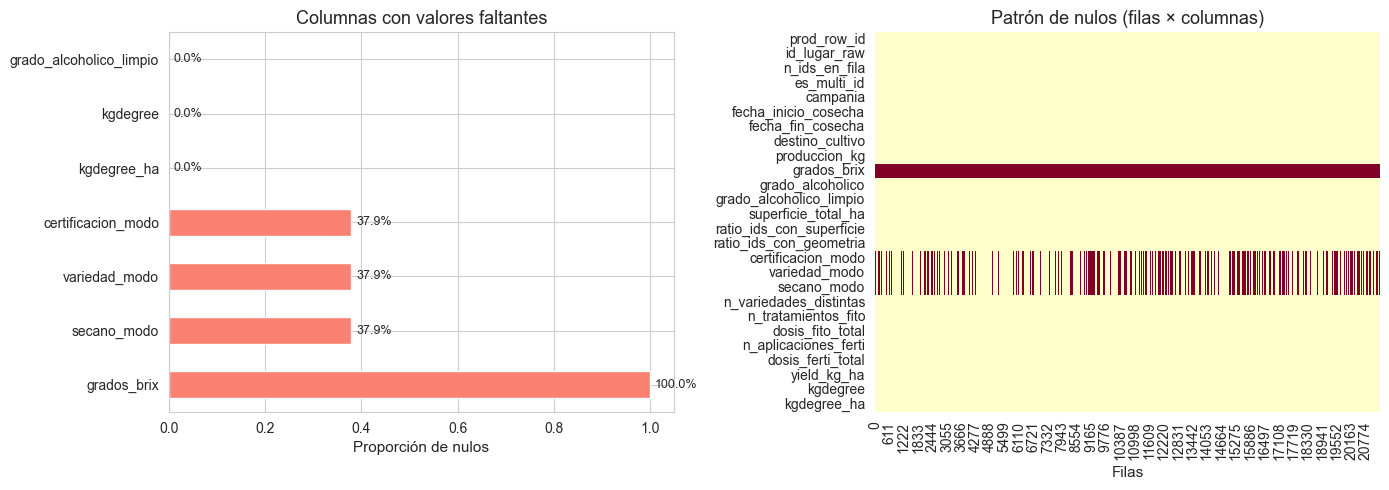


Resumen de nulos:
  grados_brix: 100.0% (21,382 filas)
  secano_modo: 37.9% (8,105 filas)
  variedad_modo: 37.9% (8,105 filas)
  certificacion_modo: 37.9% (8,105 filas)
  kgdegree_ha: 0.0% (1 filas)
  kgdegree: 0.0% (1 filas)
  grado_alcoholico_limpio: 0.0% (1 filas)


In [7]:
# Heatmap de nulos
nulos = df.isnull().mean().sort_values(ascending=False)
nulos_pct = nulos[nulos > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de % nulos
nulos_pct.plot.barh(ax=axes[0], color="salmon")
axes[0].set_xlabel("Proporción de nulos")
axes[0].set_title("Columnas con valores faltantes")
for i, v in enumerate(nulos_pct.values):
    axes[0].text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=9)

# Heatmap
sns.heatmap(
    df.isnull().T,
    cbar=False, yticklabels=True,
    cmap="YlOrRd", ax=axes[1],
)
axes[1].set_title("Patrón de nulos (filas × columnas)")
axes[1].set_xlabel("Filas")
plt.tight_layout()
plt.show()

print("\nResumen de nulos:")
for col, pct in nulos_pct.items():
    print(f"  {col}: {pct:.1%} ({df[col].isnull().sum():,} filas)")

### 1.3 Variables objetivo: distribución y outliers

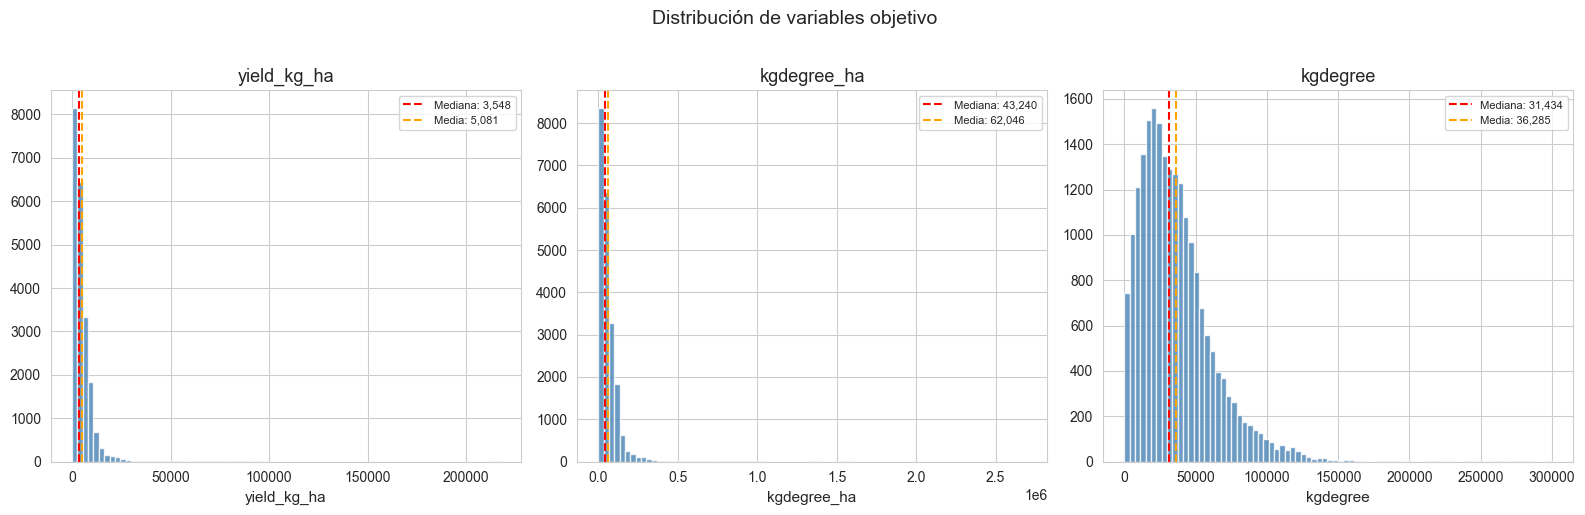


yield_kg_ha:
  Rango: [0, 216,988]
  Media: 5,081 | Mediana: 3,548
  Std: 6,461 | Skewness: 9.75
  IQR: [1,938, 6,454] → Outliers: 986 altos, 0 bajos

kgdegree_ha:
  Rango: [0, 2,690,656]
  Media: 62,046 | Mediana: 43,240
  Std: 82,954 | Skewness: 10.19
  IQR: [22,766, 78,294] → Outliers: 980 altos, 0 bajos

kgdegree:
  Rango: [0, 299,992]
  Media: 36,285 | Mediana: 31,434
  Std: 26,009 | Skewness: 1.64
  IQR: [17,547, 48,601] → Outliers: 709 altos, 0 bajos


In [8]:
targets = ["yield_kg_ha", "kgdegree_ha", "kgdegree"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, targets):
    data = df[col].dropna()
    ax.hist(data, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(data.median(), color="red", ls="--", label=f"Mediana: {data.median():,.0f}")
    ax.axvline(data.mean(), color="orange", ls="--", label=f"Media: {data.mean():,.0f}")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
plt.suptitle("Distribución de variables objetivo", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Estadísticos detallados
for col in targets:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers_high = (data > q3 + 1.5 * iqr).sum()
    outliers_low = (data < q1 - 1.5 * iqr).sum()
    print(f"\n{col}:")
    print(f"  Rango: [{data.min():,.0f}, {data.max():,.0f}]")
    print(f"  Media: {data.mean():,.0f} | Mediana: {data.median():,.0f}")
    print(f"  Std: {data.std():,.0f} | Skewness: {data.skew():.2f}")
    print(f"  IQR: [{q1:,.0f}, {q3:,.0f}] → Outliers: {outliers_high} altos, {outliers_low} bajos")

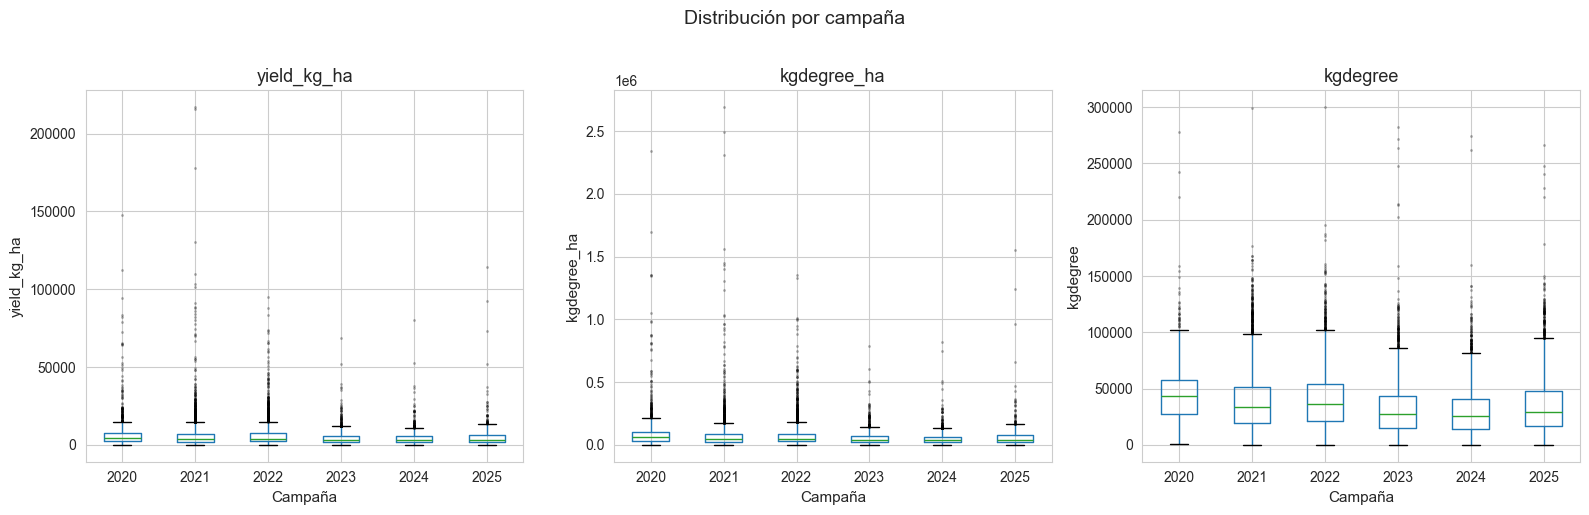

In [9]:
# Boxplots por campaña
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, targets):
    df.boxplot(column=col, by="campania", ax=ax, showfliers=True,
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_title(col)
    ax.set_xlabel("Campaña")
    ax.set_ylabel(col)
plt.suptitle("Distribución por campaña", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Patrones temporales

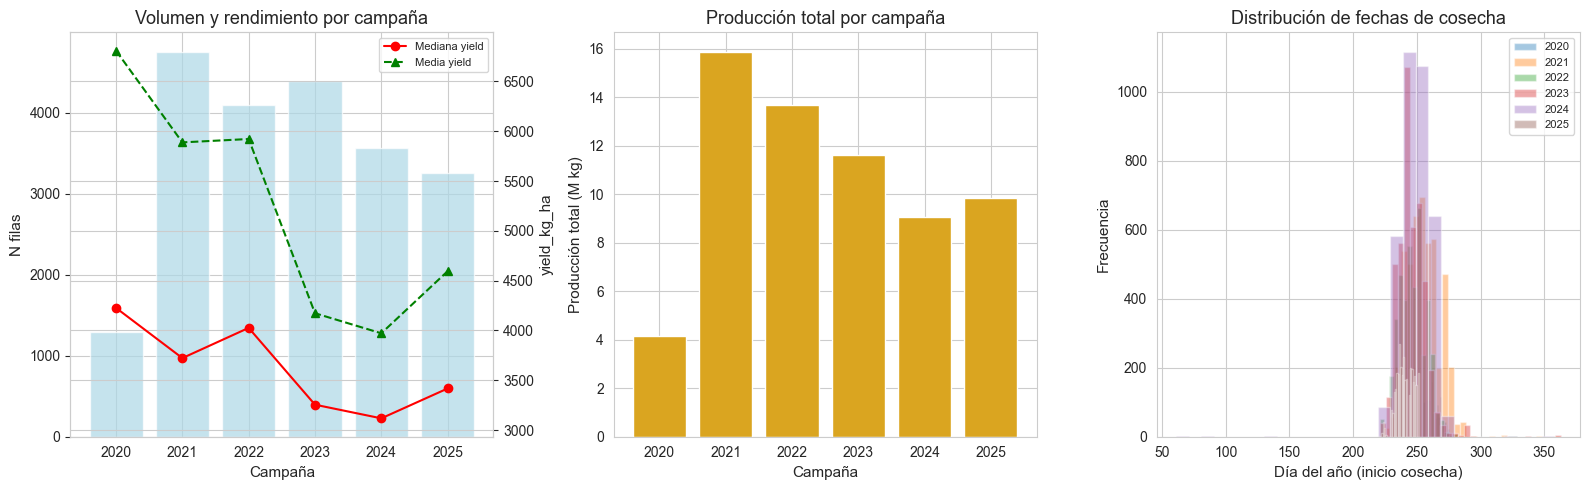

,campania,n_filas,yield_media,yield_mediana,yield_std,kgdegree_ha_media,prod_total
0,2020,1296,"6,808.59","4,225.99","9,952.39","96,314.19",4169197
1,2021,4758,"5,888.16","3,722.25","8,974.94","69,606.29",15883696
2,2022,4104,"5,921.95","4,025.54","6,835.80","73,003.95",13700069
3,2023,4397,"4,172.54","3,254.40","3,595.32","50,902.18",11606234
4,2024,3565,"3,971.25","3,117.28","3,560.73","47,027.42",9049806
5,2025,3262,"4,594.64","3,417.10","4,586.46","55,051.95",9833065


In [10]:
# Evolución temporal de rendimiento
temporal = df.groupby("campania").agg(
    n_filas=("yield_kg_ha", "count"),
    yield_media=("yield_kg_ha", "mean"),
    yield_mediana=("yield_kg_ha", "median"),
    yield_std=("yield_kg_ha", "std"),
    kgdegree_ha_media=("kgdegree_ha", "mean"),
    prod_total=("produccion_kg", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rendimiento medio por campaña
ax = axes[0]
ax.bar(temporal["campania"], temporal["n_filas"], color="lightblue", alpha=0.7, label="N filas")
ax2 = ax.twinx()
ax2.plot(temporal["campania"], temporal["yield_mediana"], "ro-", label="Mediana yield")
ax2.plot(temporal["campania"], temporal["yield_media"], "g^--", label="Media yield")
ax.set_xlabel("Campaña")
ax.set_ylabel("N filas")
ax2.set_ylabel("yield_kg_ha")
ax.set_title("Volumen y rendimiento por campaña")
ax2.legend(loc="upper right", fontsize=8)

# Producción total
ax = axes[1]
ax.bar(temporal["campania"], temporal["prod_total"] / 1e6, color="goldenrod")
ax.set_xlabel("Campaña")
ax.set_ylabel("Producción total (M kg)")
ax.set_title("Producción total por campaña")

# Distribución de fechas de cosecha
ax = axes[2]
for camp in sorted(df["campania"].dropna().unique()):
    fechas = df.loc[df["campania"] == camp, "fecha_inicio_cosecha"].dropna()
    if len(fechas) > 0:
        doy = fechas.dt.dayofyear
        ax.hist(doy, bins=30, alpha=0.4, label=f"{int(camp)}")
ax.set_xlabel("Día del año (inicio cosecha)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de fechas de cosecha")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

display(temporal)

### 1.5 Variables categóricas

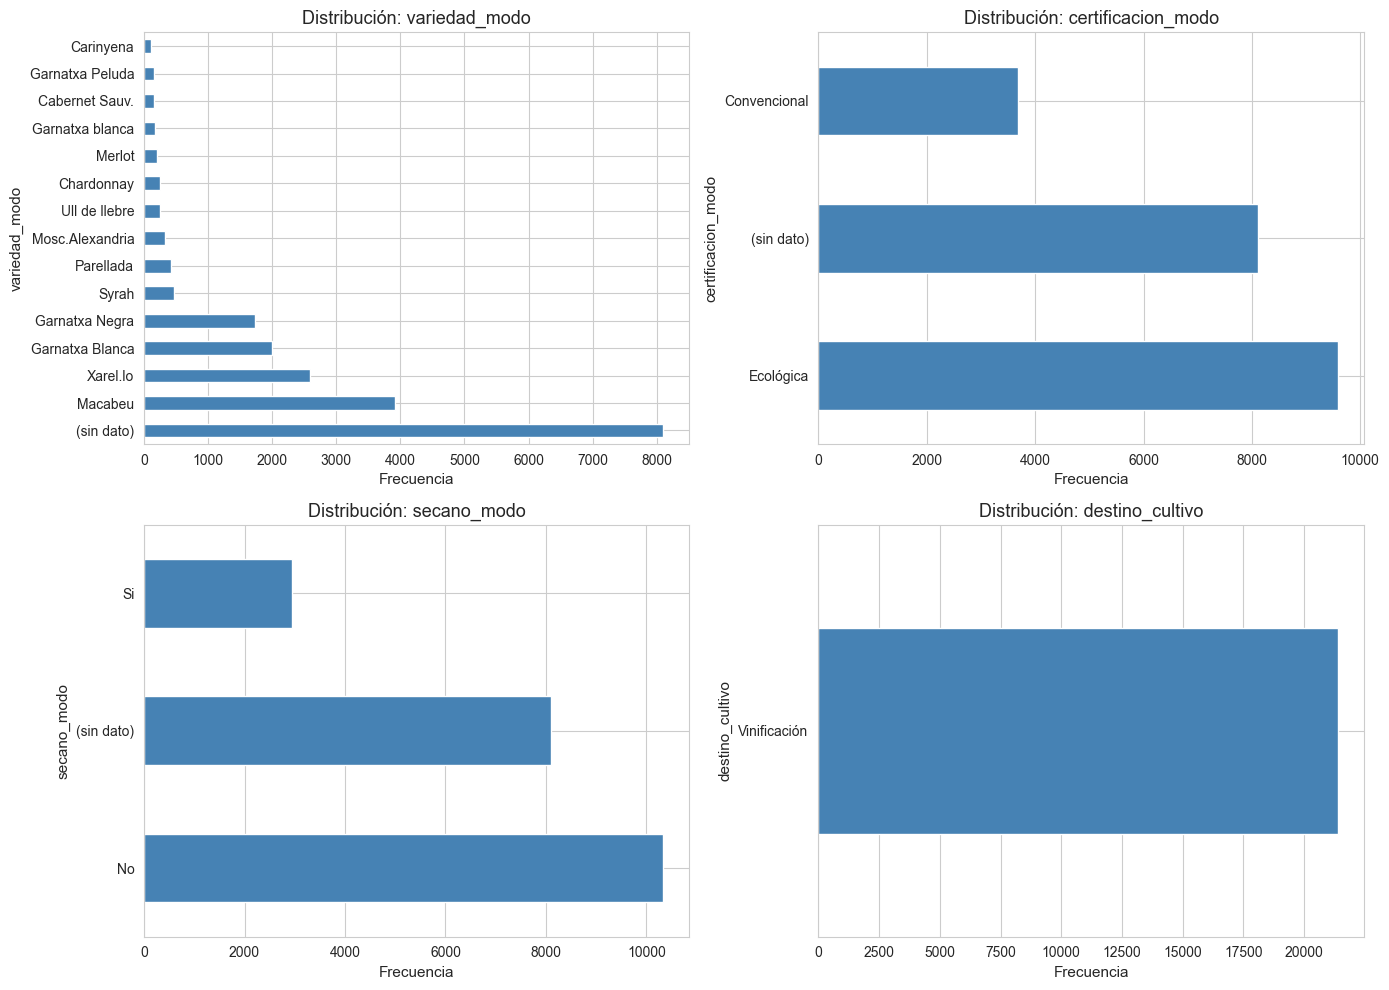

In [11]:
cat_cols = ["variedad_modo", "certificacion_modo", "secano_modo", "destino_cultivo"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].fillna("(sin dato)").value_counts().head(15)
    counts.plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"Distribución: {col}")
    ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()

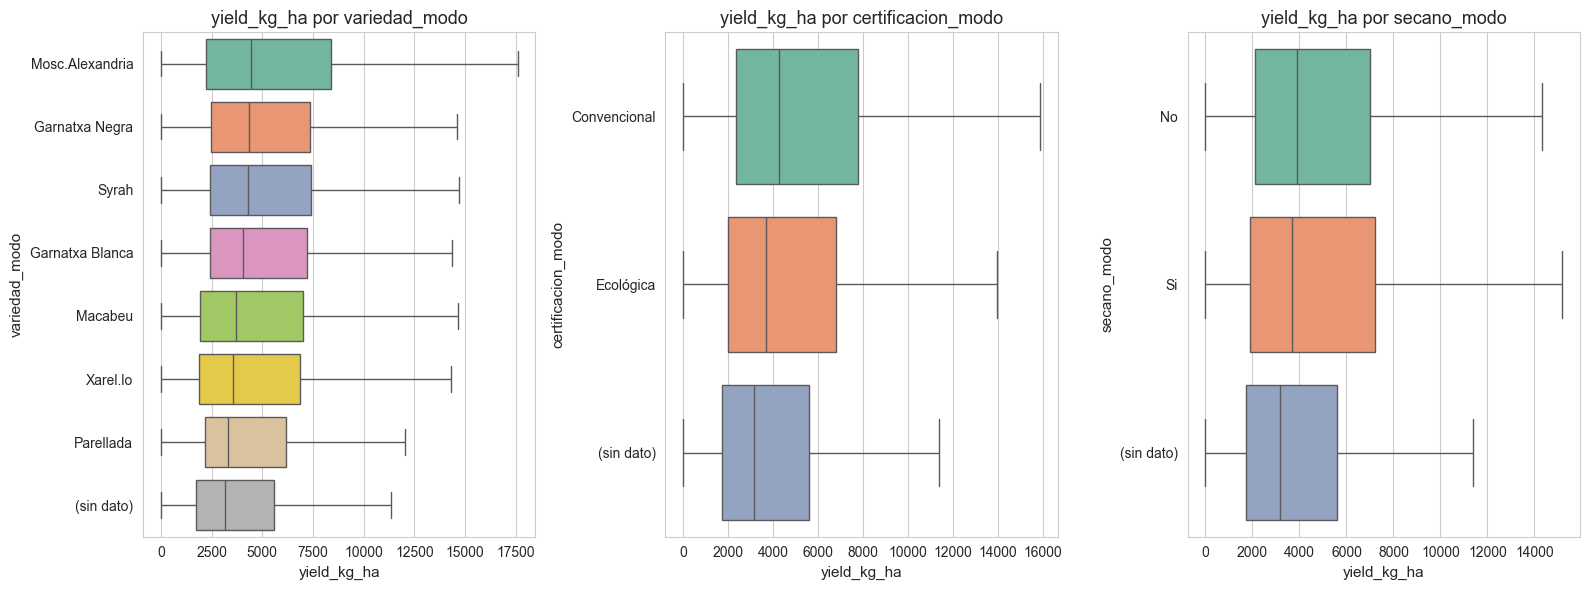

In [12]:
# Boxplot de yield por categorías principales
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, col in zip(axes, ["variedad_modo", "certificacion_modo", "secano_modo"]):
    top_cats = df[col].fillna("(sin dato)").value_counts().head(8).index
    subset = df.copy()
    subset[col] = subset[col].fillna("(sin dato)")
    subset = subset[subset[col].isin(top_cats)]

    order = (
        subset.groupby(col)["yield_kg_ha"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    sns.boxplot(
        data=subset, y=col, x="yield_kg_ha", order=order,
        ax=ax, showfliers=False, palette="Set2",
    )
    ax.set_title(f"yield_kg_ha por {col}")
    ax.set_xlabel("yield_kg_ha")
plt.tight_layout()
plt.show()

### 1.6 Variables de manejo (fitosanitarios y fertilización)

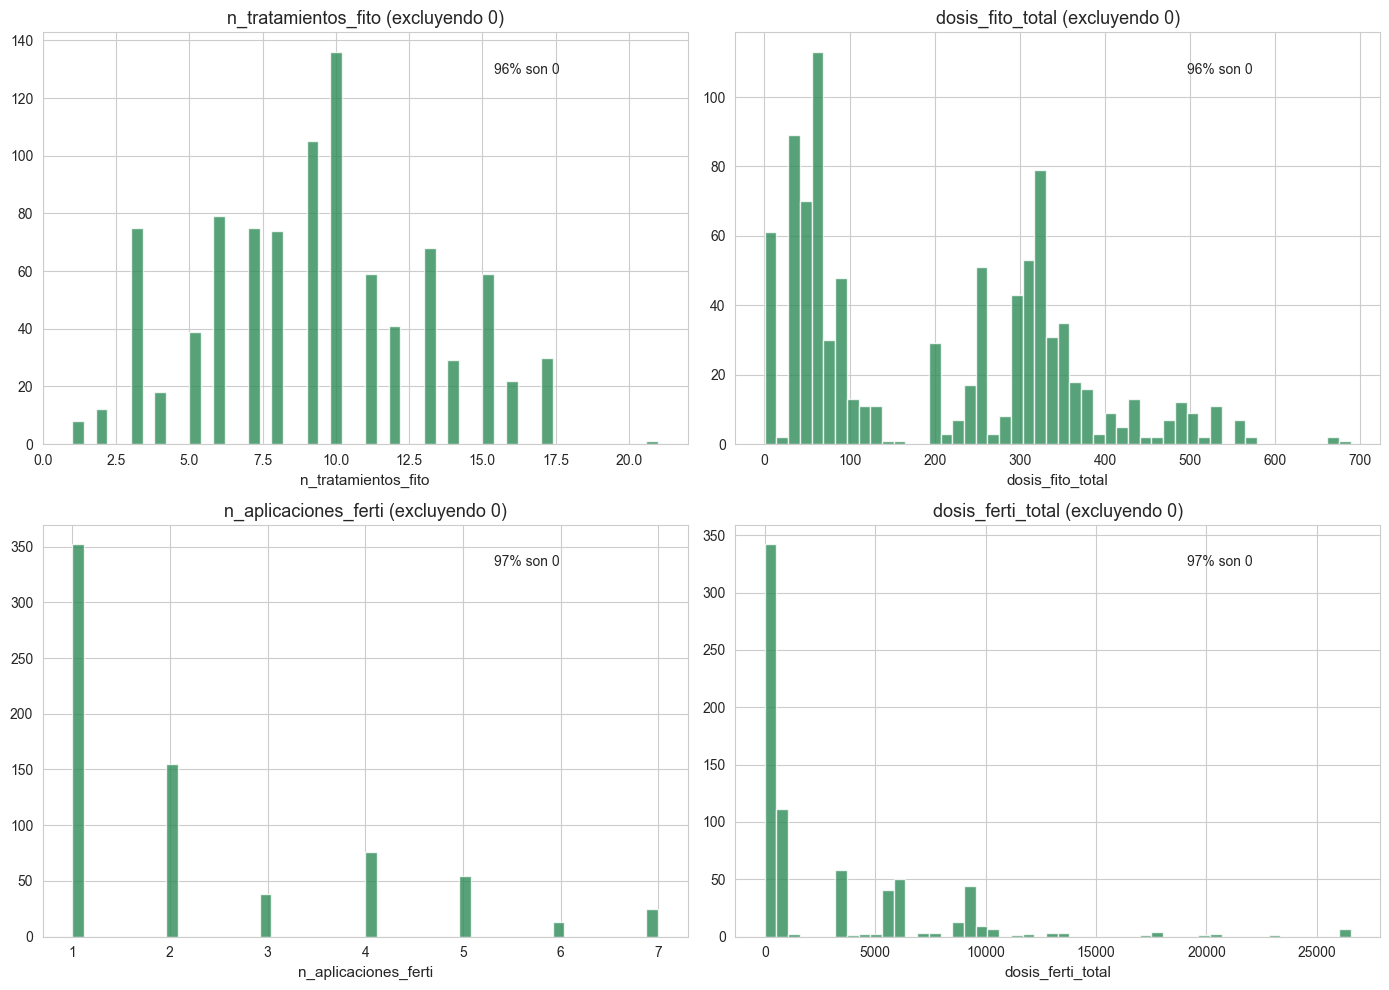

In [13]:
manejo_cols = ["n_tratamientos_fito", "dosis_fito_total", "n_aplicaciones_ferti", "dosis_ferti_total"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, manejo_cols):
    data = df[col].dropna()
    ax.hist(data[data > 0], bins=50, color="seagreen", edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} (excluyendo 0)")
    ax.set_xlabel(col)
    zeros_pct = (data == 0).mean()
    ax.annotate(f"{zeros_pct:.0%} son 0", xy=(0.7, 0.9), xycoords="axes fraction", fontsize=10)
plt.tight_layout()
plt.show()

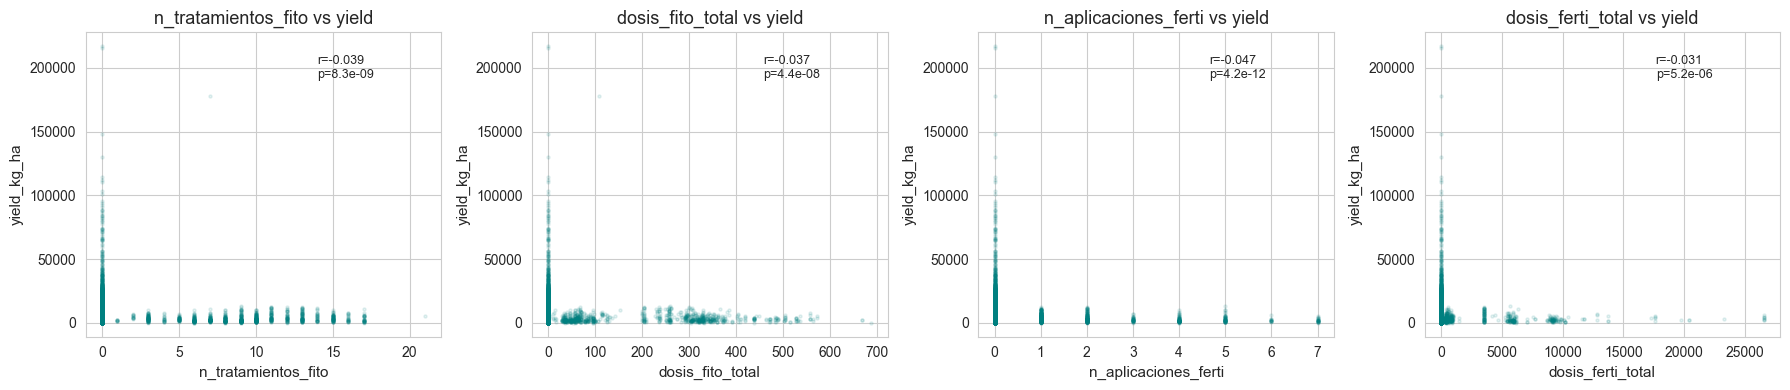

In [14]:
# Scatter: manejo vs yield
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, manejo_cols):
    ax.scatter(df[col], df["yield_kg_ha"], alpha=0.1, s=5, c="teal")
    ax.set_xlabel(col)
    ax.set_ylabel("yield_kg_ha")
    ax.set_title(f"{col} vs yield")
    # Correlación
    mask = df[[col, "yield_kg_ha"]].dropna().index
    if len(mask) > 10:
        r, p = stats.pearsonr(df.loc[mask, col], df.loc[mask, "yield_kg_ha"])
        ax.annotate(f"r={r:.3f}\np={p:.1e}", xy=(0.65, 0.85), xycoords="axes fraction", fontsize=9)
plt.tight_layout()
plt.show()

### 1.7 Matriz de correlaciones

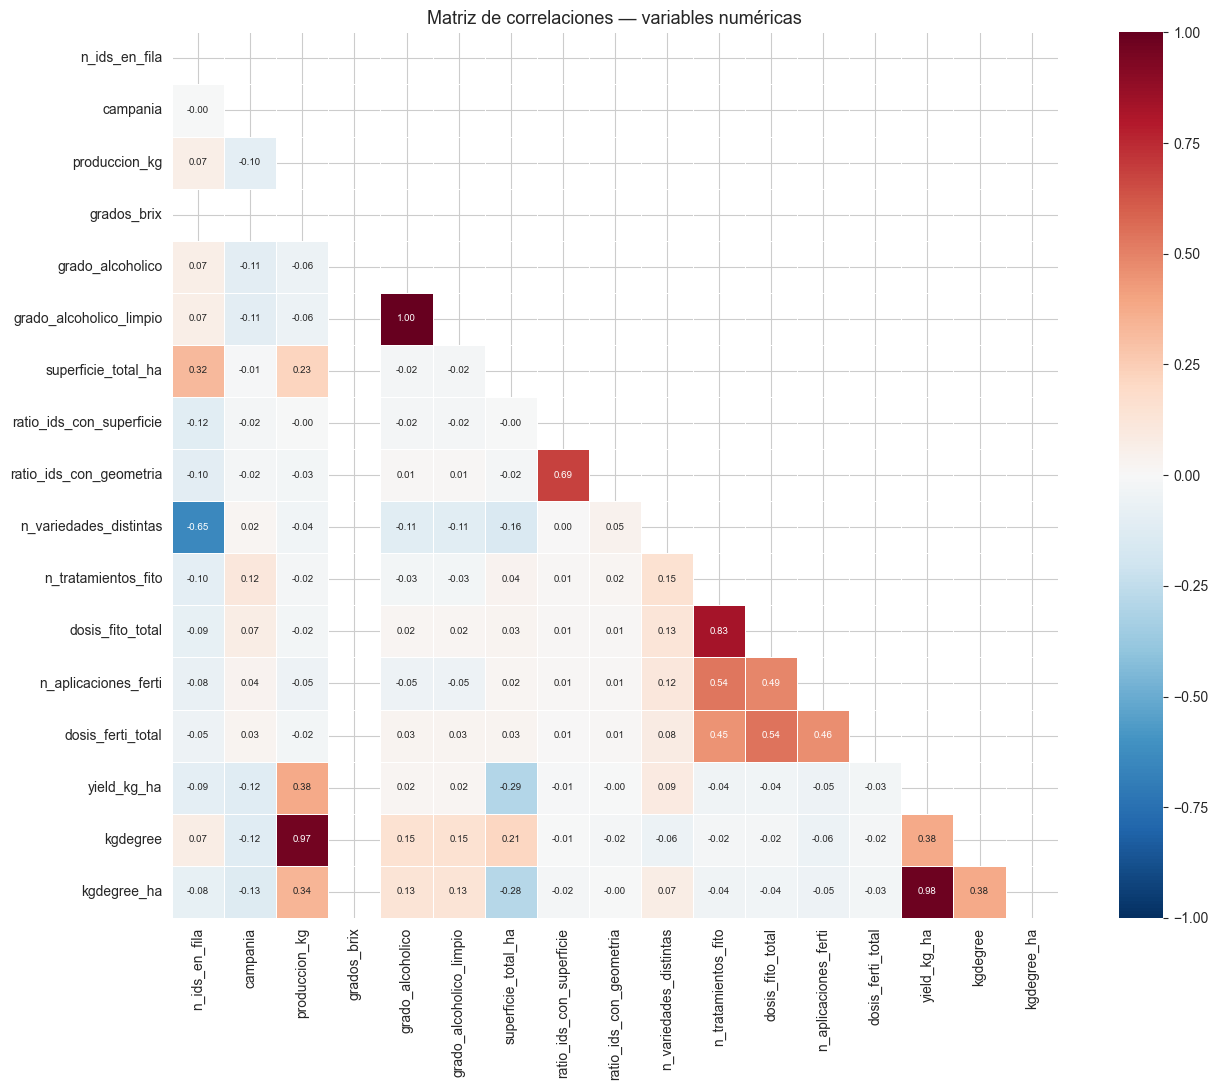


Top correlaciones con yield_kg_ha:
  +0.983  kgdegree_ha
  +0.378  kgdegree
  +0.377  produccion_kg
  -0.293  superficie_total_ha
  -0.120  campania
  -0.094  n_ids_en_fila
  +0.086  n_variedades_distintas
  -0.047  n_aplicaciones_ferti
  -0.039  n_tratamientos_fito
  -0.037  dosis_fito_total


In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluir IDs y ratios poco informativos
exclude = ["prod_row_id"]
num_cols = [c for c in num_cols if c not in exclude]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    ax=ax, annot_kws={"fontsize": 7},
)
ax.set_title("Matriz de correlaciones — variables numéricas")
plt.tight_layout()
plt.show()

# Top correlaciones con yield_kg_ha
print("\nTop correlaciones con yield_kg_ha:")
yield_corr = corr["yield_kg_ha"].drop("yield_kg_ha").abs().sort_values(ascending=False)
for col, val in yield_corr.head(10).items():
    sign = "+" if corr.loc[col, "yield_kg_ha"] > 0 else "-"
    print(f"  {sign}{val:.3f}  {col}")

## 2. Tabla AOI y geometrías de parcela

### 2.1 Carga de la tabla AOI (25 parcelas)

In [16]:
aoi = pd.read_csv(AOI_CSV, encoding="utf-8-sig")
aoi["geom"] = aoi["geometry"].apply(wkt.loads)
aoi["geom_4326"] = aoi["geom"].apply(reproject_to_4326)
aoi["area_ha"] = aoi["geom_4326"].apply(lambda g: g.area * 111320**2 * np.cos(np.radians(g.centroid.y)) / 1e4)
# Área más precisa usando las coordenadas proyectadas (m² en 3857)
aoi["area_ha_proj"] = aoi["geom"].apply(lambda g: g.area / 1e4)
aoi["centroid_lat"] = aoi["geom_4326"].apply(lambda g: g.centroid.y)
aoi["centroid_lon"] = aoi["geom_4326"].apply(lambda g: g.centroid.x)

print(f"Parcelas AOI: {len(aoi)}")
print(f"Provincia: {aoi['provincia'].unique()}, Municipio: {aoi['municipio'].unique()}")
display(aoi[["parcel_id", "provincia", "municipio", "poligono", "parcela", "area_ha_proj", "centroid_lat", "centroid_lon"]].head(10))

Parcelas AOI: 25
Provincia: [8], Municipio: [13 84]


,parcel_id,provincia,municipio,poligono,parcela,area_ha_proj,centroid_lat,centroid_lon
0,L188,8,13,1,2,2.59,41.39,1.75
1,L189,8,13,1,7,0.87,41.39,1.74
2,L190,8,13,1,8,0.19,41.39,1.74
3,L191,8,13,1,9,2.38,41.39,1.74
4,L192,8,13,1,13,9.33,41.39,1.74
5,L193,8,13,1,21,1.40,41.38,1.74
6,L197,8,13,1,22,0.34,41.38,1.74
7,L199,8,13,1,23,1.45,41.38,1.74
8,L1100,8,13,1,24,0.88,41.38,1.74
9,L194,8,13,1,25,6.94,41.38,1.73


### 2.2 Full AOI table (mapeo ID_Lugar → SIGPAC)

In [17]:
full_aoi_path = RAW_DIR / "Full_aoi_table.xlsx"
if full_aoi_path.exists():
    full_aoi = pd.read_excel(full_aoi_path)
    full_aoi = clean_columns(full_aoi)
    print(f"Full AOI table: {len(full_aoi):,} filas × {full_aoi.shape[1]} columnas")
    print(f"Columnas: {list(full_aoi.columns)}")
    display(full_aoi.head())
else:
    print("Full AOI table no encontrada")
    full_aoi = None

Full AOI table: 7,651 filas × 9 columnas
Columnas: ['id_lugar', 'provincia', 'municipio', 'agregado', 'zona', 'poligono', 'parcela', 'recinto', 'geometry']


,id_lugar,provincia,municipio,agregado,zona,poligono,parcela,recinto,geometry
0,L512135,8,13,0,0,1,2,1,"POLYGON ((194389.3852284706 5070587.14049427, 194276.451..."
1,L512136,8,13,0,0,1,2,3,"POLYGON ((194289.03764298686 5070495.771544889, 194264.6..."
2,L512137,8,13,0,0,1,2,4,"POLYGON ((194410.16850621972 5070544.24944548, 194276.13..."
3,L512138,8,13,0,0,1,2,5,"POLYGON ((194394.32424392397 5070526.158030602, 194276.0..."
4,L512160,8,13,0,0,1,7,1,"POLYGON ((193937.2588729181 5069961.927892563, 193938.07..."


### 2.3 Mapa interactivo de parcelas AOI

In [18]:
# Centroide medio para centrar mapa
center_lat = aoi["centroid_lat"].mean()
center_lon = aoi["centroid_lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles="OpenStreetMap")
folium.TileLayer("Esri.WorldImagery", name="Satélite", attr="Esri").add_to(m)

for _, row in aoi.iterrows():
    geojson = mapping(row["geom_4326"])
    folium.GeoJson(
        geojson,
        style_function=lambda x: {
            "fillColor": "#228B22",
            "color": "#006400",
            "weight": 2,
            "fillOpacity": 0.3,
        },
        tooltip=f"{row['parcel_id']} ({row['area_ha_proj']:.2f} ha)",
    ).add_to(m)
    # Label
    folium.Marker(
        [row["centroid_lat"], row["centroid_lon"]],
        icon=folium.DivIcon(html=f'<div style="font-size:9px;font-weight:bold;color:white;text-shadow:1px 1px black">{row["parcel_id"]}</div>'),
    ).add_to(m)

folium.LayerControl().add_to(m)
m

### 2.4 Tabla resumen de parcelas

In [19]:
# Verificar cuáles parcelas AOI tienen datos agrícolas
all_ids_agro = set()
for raw in df["id_lugar_raw"].dropna():
    all_ids_agro.update(split_ids(raw))

aoi["tiene_datos_agro"] = aoi["parcel_id"].isin(all_ids_agro)
n_con_datos = aoi["tiene_datos_agro"].sum()
n_sin_datos = (~aoi["tiene_datos_agro"]).sum()

print(f"Parcelas AOI con datos agrícolas: {n_con_datos}/{len(aoi)}")
print(f"Parcelas AOI sin datos agrícolas: {n_sin_datos}")
if n_sin_datos > 0:
    print(f"  Sin datos: {aoi.loc[~aoi['tiene_datos_agro'], 'parcel_id'].tolist()}")

resumen_parcelas = aoi[["parcel_id", "poligono", "parcela", "area_ha_proj", "centroid_lat", "centroid_lon", "tiene_datos_agro"]].copy()
resumen_parcelas.columns = ["parcel_id", "polígono", "parcela", "área_ha", "lat", "lon", "datos_agro"]
display(resumen_parcelas.sort_values("parcel_id"))

Parcelas AOI con datos agrícolas: 21/25
Parcelas AOI sin datos agrícolas: 4
  Sin datos: ['L1105', 'L1106', 'L1107', 'L1108']


,parcel_id,polígono,parcela,área_ha,lat,lon,datos_agro
8,L1100,1,24,0.88,41.38,1.74,True
13,L1101,11,44,2.38,41.41,1.69,True
22,L1102,4,68,0.60,41.38,1.78,True
14,L1103,13,7,2.38,41.40,1.68,True
15,L1104,14,25,1.26,41.40,1.69,True
16,L1105,14,63,3.01,41.40,1.68,False
17,L1106,14,67,1.06,41.40,1.68,False
18,L1107,14,83,1.26,41.39,1.69,False
19,L1108,14,90,1.77,41.39,1.69,False
20,L1109,14,93,1.35,41.39,1.69,True


## 3. Estrategia de enlace agro-satélite

### 3.1 Mapeo de identificadores

In [20]:
# Explotar multi-IDs y encontrar filas enlazables con parcelas AOI
aoi_ids = set(aoi["parcel_id"].tolist())

df["ids_lista"] = df["id_lugar_raw"].apply(split_ids)
df["tiene_aoi"] = df["ids_lista"].apply(lambda ids: any(i in aoi_ids for i in ids))
df["ids_aoi"] = df["ids_lista"].apply(lambda ids: [i for i in ids if i in aoi_ids])

n_enlazables = df["tiene_aoi"].sum()
print(f"Filas con al menos un ID en AOI: {n_enlazables:,} / {len(df):,} ({n_enlazables/len(df):.1%})")
print(f"Campañas enlazables: {sorted(df.loc[df['tiene_aoi'], 'campania'].dropna().unique().astype(int))}")

# Distribución por campaña
enlace_por_camp = df[df["tiene_aoi"]].groupby("campania").size()
print(f"\nFilas enlazables por campaña:")
for camp, n in enlace_por_camp.items():
    print(f"  {int(camp)}: {n} filas")

Filas con al menos un ID en AOI: 111 / 21,382 (0.5%)
Campañas enlazables: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Filas enlazables por campaña:
  2020: 4 filas
  2021: 36 filas
  2022: 22 filas
  2023: 20 filas
  2024: 21 filas
  2025: 8 filas


In [35]:
# IDs AOI que aparecen en datos agrícolas
ids_en_agro = set()
for ids in df.loc[df["tiene_aoi"], "ids_lista"]:
    ids_en_agro.update(i for i in ids if i in aoi_ids)

ids_sin_produccion = aoi_ids - ids_en_agro
print(f"IDs AOI con producción: {len(ids_en_agro)} / {len(aoi_ids)}")
print(f"IDs AOI sin producción: {ids_sin_produccion if ids_sin_produccion else '(ninguno)'}")

# Vista previa de filas enlazables
df[df["tiene_aoi"]][["id_lugar_raw", "campania", "yield_kg_ha", "variedad_modo", "superficie_total_ha", "ids_aoi"]].head(20)
# display(
# )

IDs AOI con producción: 21 / 25
IDs AOI sin producción: {'L1105', 'L1106', 'L1107', 'L1108'}


,id_lugar_raw,campania,yield_kg_ha,variedad_modo,superficie_total_ha,ids_aoi
2,"L198, L1111",2020,"1,332.96",NaN,0.35,"[L198, L1111]"
3,L196,2020,"1,597.01",Petit Verdot,0.29,[L196]
4,L1102,2020,"1,558.37",Petit Verdot,0.34,[L1102]
8,"L188, L191, L197",2020,910.71,NaN,0.62,"[L188, L191, L197]"
10,"L171, L184, L192, L199",2021,"4,663.86",NaN,0.40,"[L192, L199]"
12,"L171, L184, L192, L199",2021,"4,887.12",NaN,0.40,"[L192, L199]"
27,"L194, L1100",2021,"1,998.99",NaN,1.19,"[L194, L1100]"
30,"L188, L191, L197",2021,"4,593.98",NaN,0.62,"[L188, L191, L197]"
31,"L188, L191, L197",2021,"7,004.21",NaN,0.62,"[L188, L191, L197]"
32,L1104,2021,"10,015.02",Moscatell de gra petit,0.20,[L1104]


### 3.2 Ventanas fenológicas del viñedo

In [22]:
# Definición de fases fenológicas del viñedo en el hemisferio norte (latitudes ~41°N)
fenologia = pd.DataFrame([
    {"fase": "Dormancia", "inicio_mes": 12, "fin_mes": 2, "inicio_aprox": "01-dic", "fin_aprox": "28-feb",
     "descripcion": "Reposo vegetativo invernal"},
    {"fase": "Brotación", "inicio_mes": 3, "fin_mes": 4, "inicio_aprox": "01-mar", "fin_aprox": "30-abr",
     "descripcion": "Desborre y crecimiento inicial de brotes"},
    {"fase": "Floración", "inicio_mes": 5, "fin_mes": 6, "inicio_aprox": "01-may", "fin_aprox": "15-jun",
     "descripcion": "Floración y cuajado del fruto"},
    {"fase": "Envero", "inicio_mes": 7, "fin_mes": 7, "inicio_aprox": "01-jul", "fin_aprox": "31-jul",
     "descripcion": "Cambio de color de las bayas, inicio maduración"},
    {"fase": "Maduración", "inicio_mes": 8, "fin_mes": 8, "inicio_aprox": "01-ago", "fin_aprox": "31-ago",
     "descripcion": "Acumulación de azúcares, desarrollo aromático"},
    {"fase": "Cosecha", "inicio_mes": 9, "fin_mes": 10, "inicio_aprox": "01-sep", "fin_aprox": "31-oct",
     "descripcion": "Vendimia"},
])

print("Ventanas fenológicas del viñedo (Cataluña, ~41°N):")
display(fenologia)

# Verificar con fechas reales de cosecha
print("\nValidación con datos reales de cosecha:")
cosecha_mes = df["fecha_inicio_cosecha"].dropna().dt.month
print(f"  Meses de inicio de cosecha: {sorted(cosecha_mes.unique())}")
print(f"  Mediana: mes {int(cosecha_mes.median())} ({cosecha_mes.mode().iloc[0]})")

Ventanas fenológicas del viñedo (Cataluña, ~41°N):


,fase,inicio_mes,fin_mes,inicio_aprox,fin_aprox,descripcion
0,Dormancia,12,2,01-dic,28-feb,Reposo vegetativo invernal
1,Brotación,3,4,01-mar,30-abr,Desborre y crecimiento inicial de brotes
2,Floración,5,6,01-may,15-jun,Floración y cuajado del fruto
3,Envero,7,7,01-jul,31-jul,"Cambio de color de las bayas, inicio maduración"
4,Maduración,8,8,01-ago,31-ago,"Acumulación de azúcares, desarrollo aromático"
5,Cosecha,9,10,01-sep,31-oct,Vendimia



Validación con datos reales de cosecha:
  Meses de inicio de cosecha: [np.int32(3), np.int32(5), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  Mediana: mes 9 (9)


### 3.3 Matriz de cobertura cruzada

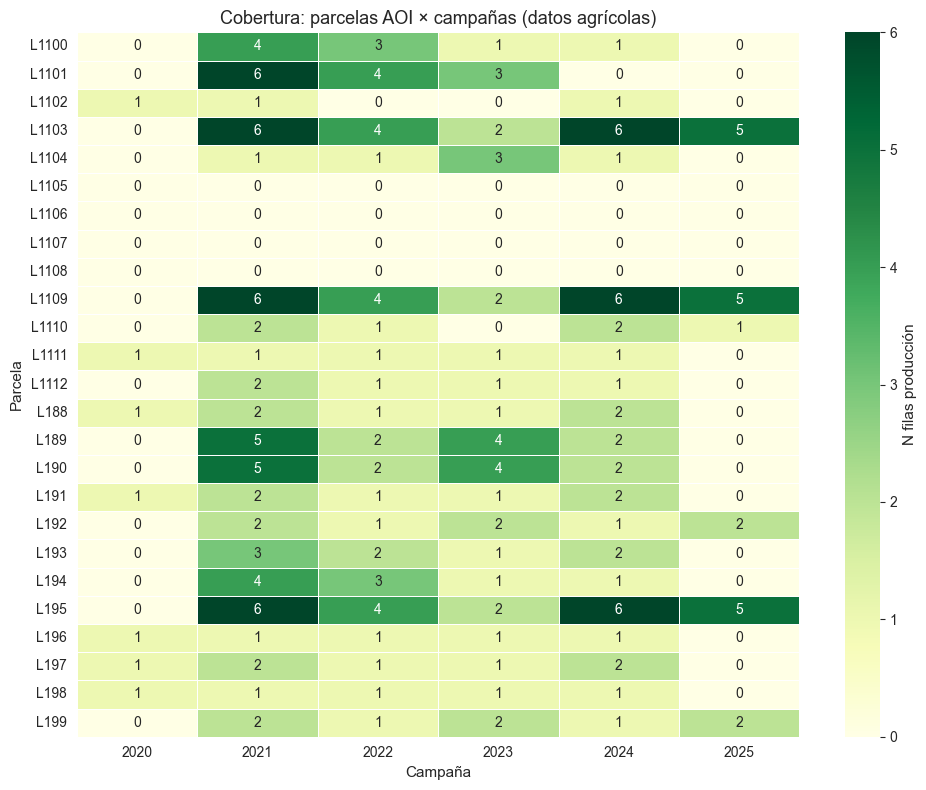


Total observaciones enlazables (parcela × campaña): 206
Parcelas únicas con datos: 21
Campañas cubiertas: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [23]:
# Crear tabla de parcela × campaña con datos agrícolas
rows = []
for _, row in df[df["tiene_aoi"]].iterrows():
    for pid in row["ids_aoi"]:
        rows.append({
            "parcel_id": pid,
            "campania": int(row["campania"]),
            "yield_kg_ha": row["yield_kg_ha"],
        })
cobertura = pd.DataFrame(rows)

# Pivot: parcela × campaña
pivot_agro = cobertura.pivot_table(
    index="parcel_id", columns="campania", values="yield_kg_ha",
    aggfunc="count", fill_value=0,
)

# Añadir parcelas sin datos
for pid in aoi_ids:
    if pid not in pivot_agro.index:
        pivot_agro.loc[pid] = 0

pivot_agro = pivot_agro.sort_index()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot_agro.astype(int), annot=True, fmt="d", cmap="YlGn",
    linewidths=0.5, ax=ax, cbar_kws={"label": "N filas producción"},
)
ax.set_title("Cobertura: parcelas AOI × campañas (datos agrícolas)")
ax.set_xlabel("Campaña")
ax.set_ylabel("Parcela")
plt.tight_layout()
plt.show()

print(f"\nTotal observaciones enlazables (parcela × campaña): {cobertura.shape[0]}")
print(f"Parcelas únicas con datos: {cobertura['parcel_id'].nunique()}")
print(f"Campañas cubiertas: {sorted(cobertura['campania'].unique())}")

## 4. Inventario de datos satelitales descargados

### 4.1 Escaneo automático de archivos

In [24]:
SENSOR_FOLDERS = {
    "S1": "SENTINEL-1",
    "S2": "SENTINEL-2",
    "S3": "SENTINEL-3",
    "MODIS": "MODIS",
    "ERA5": "ERA5",
}

inventario = {}
for sensor_key, folder_name in SENSOR_FOLDERS.items():
    sensor_dir = SAT_OUTPUT / folder_name
    if not sensor_dir.is_dir():
        inventario[sensor_key] = {"status": "Sin directorio", "scenes": 0, "parcels": []}
        continue

    # Buscar subdirectorios de parcelas (batch mode: Lxxx)
    parcel_dirs = [d for d in sorted(sensor_dir.iterdir()) if d.is_dir() and d.name.startswith("L")]

    if parcel_dirs:
        # Batch mode
        scenes_total = 0
        for pd_dir in parcel_dirs:
            scenes = [d for d in pd_dir.iterdir() if d.is_dir() and not d.name.startswith(".") and d.name != "cube.zarr"]
            scenes_total += len(scenes)
        inventario[sensor_key] = {
            "status": f"Batch ({len(parcel_dirs)} parcelas)",
            "scenes": scenes_total,
            "parcels": [d.name for d in parcel_dirs],
        }
    else:
        # Single mode
        scenes = [d for d in sensor_dir.iterdir() if d.is_dir() and not d.name.startswith(".") and d.name != "cube.zarr"]
        zarr = sensor_dir / "cube.zarr"
        inventario[sensor_key] = {
            "status": f"Single mode ({len(scenes)} escenas)" + (" + Zarr cube" if zarr.is_dir() else ""),
            "scenes": len(scenes),
            "parcels": ["(global)"],
        }

print("Inventario de datos satelitales descargados:\n")
for sensor, info in inventario.items():
    print(f"  {sensor}: {info['status']}")
    if info["scenes"] > 0:
        print(f"     Escenas: {info['scenes']}")
    if info["parcels"] and info["parcels"] != ["(global)"]:
        print(f"     Parcelas: {info['parcels']}")

Inventario de datos satelitales descargados:

  S1: Sin directorio
  S2: Single mode (1 escenas) + Zarr cube
     Escenas: 1
  S3: Sin directorio
  MODIS: Sin directorio
  ERA5: Sin directorio


### 4.2 Calidad de escenas S2

In [25]:
s2_dir = SAT_OUTPUT / "SENTINEL-2"
quality_info = []

if s2_dir.is_dir():
    # Buscar escenas (single mode o batch)
    scene_dirs = [d for d in s2_dir.iterdir() if d.is_dir() and d.name.startswith("S2")]

    for scene_dir in scene_dirs:
        # Buscar QUALITY JSON
        quality_jsons = list(scene_dir.glob("QUALITY_*.json"))
        if quality_jsons:
            with open(quality_jsons[0]) as f:
                qdata = json.load(f)
            quality_info.append({
                "escena": scene_dir.name,
                **{k: v for k, v in qdata.items() if not isinstance(v, (dict, list))},
            })

        # Listar bandas disponibles
        bands = [f.stem.split("_")[0] for f in sorted(scene_dir.glob("*.tif"))]
        bands = list(dict.fromkeys(bands))  # unique preserving order
        print(f"Escena: {scene_dir.name}")
        print(f"  Bandas: {bands}")

        # Calidad por banda
        for band in bands:
            bq_files = list(scene_dir.glob(f"{band}_*.quality.json"))
            if bq_files:
                with open(bq_files[0]) as f:
                    bq = json.load(f)
                print(f"  {band}: {bq}")

if quality_info:
    print("\nResumen de calidad de escenas:")
    display(pd.DataFrame(quality_info))
else:
    print("No se encontraron archivos de calidad JSON.")

Escena: S2A_MSIL2A_20240509T105031_R051_T31TCG_20240509T160957
  Bandas: ['B04', 'B08', 'NDVI']
  B04: {'derived_file': 'B04_S2A_MSIL2A_20240509T105031_R051_T31TCG_20240509T160957_parcel.tif', 'derived_product': 'B04', 'scene_id': 'S2A_MSIL2A_20240509T105031_R051_T31TCG_20240509T160957', 'collection': 'sentinel-2-l2a', 'mgrs_tile': '31TCG', 'native_epsg': 4326, 'crop_bbox_epsg4326': [0.9597768844469516, 41.68932715070245, 1.0161577773875066, 41.7275214342394], 'crop_bbox_epsg3857': [106841.87405178921, 5114555.165676923, 113118.16634440186, 5120250.461740777], 'aoi_polygon_epsg4326': {'type': 'Polygon', 'coordinates': [[[0.960675199731071, 41.726851001372324], [0.960675199731071, 41.689997975000324], [1.015259462103387, 41.689997975000324], [1.015259462103387, 41.726851001372324], [0.960675199731071, 41.726851001372324]]]}, 'quality_indicators': {'stac_subset': {'eo:cloud_cover': 0.298018, 's2:nodata_pixel_percentage': 1.3e-05, 's2:saturated_defective_pixel_percentage': 0.0, 's2:dark_f

,escena,scene_id,collection,mgrs_tile,acquisition_start,acquisition_end,native_epsg
0,S2A_MSIL2A_20240509T105031_R051_T31TCG_20240509T160957,S2A_MSIL2A_20240509T105031_R051_T31TCG_20240509T160957,sentinel-2-l2a,31TCG,2024-05-09T10:50:31Z,2024-05-09T10:50:31Z,4326


### 4.3 Visualización: NDVI de la escena S2 disponible

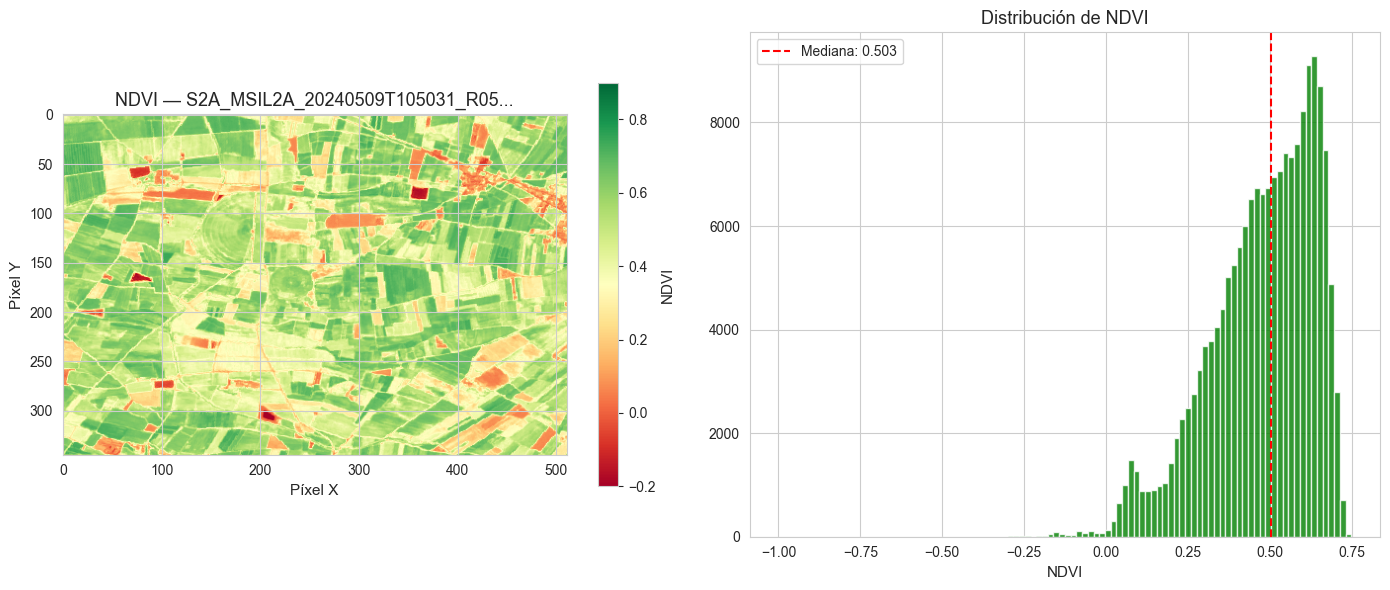

Shape: (345, 511)
CRS: EPSG:4326
Bounds: BoundingBox(left=0.9606259586666667, bottom=41.68996228070423, right=1.0153087013333333, top=41.72688629929578)
NDVI válido: [-1.000, 0.749]
NDVI medio: 0.476


In [26]:
# Intentar cargar la escena NDVI S2
s2_scenes = list((SAT_OUTPUT / "SENTINEL-2").glob("S2*")) if (SAT_OUTPUT / "SENTINEL-2").is_dir() else []

if s2_scenes:
    scene_dir = s2_scenes[0]
    ndvi_files = list(scene_dir.glob("NDVI_*.tif"))

    if ndvi_files:
        with rasterio.open(ndvi_files[0]) as src:
            ndvi = src.read(1).astype(np.float32)
            profile = dict(src.profile)
            bounds = src.bounds
            crs = src.crs

        # Máscara de nodata
        ndvi_masked = np.where((ndvi < -1) | (ndvi > 1), np.nan, ndvi)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Mapa NDVI
        im = axes[0].imshow(ndvi_masked, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
        axes[0].set_title(f"NDVI — {scene_dir.name[:30]}...")
        plt.colorbar(im, ax=axes[0], label="NDVI", shrink=0.8)
        axes[0].set_xlabel("Píxel X")
        axes[0].set_ylabel("Píxel Y")

        # Histograma
        valid = ndvi_masked[~np.isnan(ndvi_masked)]
        axes[1].hist(valid, bins=100, color="green", edgecolor="white", alpha=0.8)
        axes[1].axvline(np.nanmedian(ndvi_masked), color="red", ls="--",
                       label=f"Mediana: {np.nanmedian(ndvi_masked):.3f}")
        axes[1].set_title("Distribución de NDVI")
        axes[1].set_xlabel("NDVI")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f"Shape: {ndvi.shape}")
        print(f"CRS: {crs}")
        print(f"Bounds: {bounds}")
        print(f"NDVI válido: [{np.nanmin(ndvi_masked):.3f}, {np.nanmax(ndvi_masked):.3f}]")
        print(f"NDVI medio: {np.nanmean(ndvi_masked):.3f}")
    else:
        print("No se encontró banda NDVI en la escena S2.")
else:
    print("No hay escenas S2 descargadas.")

### 4.4 Inventario objetivo de descarga

In [27]:
# Lo que tenemos vs. lo que necesitamos
campanias = sorted(df.loc[df["tiene_aoi"], "campania"].dropna().unique().astype(int))
n_parcelas = len(aoi_ids)
sensores = ["S2", "ERA5", "S1", "MODIS", "S3"]

print("INVENTARIO OBJETIVO DE DESCARGA")
print("=" * 60)
print(f"Parcelas AOI: {n_parcelas}")
print(f"Campañas con datos agrícolas: {campanias}")
print(f"Sensores planificados: {sensores}")
print()

total_descargas = 0
for sensor in sensores:
    descargado = inventario.get(sensor, {}).get("scenes", 0)
    # Estimación: cada parcela × campaña necesita ~N escenas dependiendo del sensor
    escenas_por_camp = {"S2": 20, "S1": 30, "ERA5": 365, "MODIS": 46, "S3": 20}
    objetivo = n_parcelas * len(campanias) * escenas_por_camp.get(sensor, 10)
    total_descargas += objetivo
    print(f"  {sensor}:")
    print(f"    Descargado: {descargado} escenas")
    print(f"    Objetivo aprox: {n_parcelas} parcelas × {len(campanias)} campañas × ~{escenas_por_camp.get(sensor, 10)} escenas/campaña = ~{objetivo:,}")

print(f"\nTotal escenas objetivo (aproximado): ~{total_descargas:,}")
print("\nNota: Las cifras son estimaciones. El número real depende de la")
print("cobertura de nubes (S2), disponibilidad temporal, y resolución deseada.")

INVENTARIO OBJETIVO DE DESCARGA
Parcelas AOI: 25
Campañas con datos agrícolas: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Sensores planificados: ['S2', 'ERA5', 'S1', 'MODIS', 'S3']

  S2:
    Descargado: 1 escenas
    Objetivo aprox: 25 parcelas × 6 campañas × ~20 escenas/campaña = ~3,000
  ERA5:
    Descargado: 0 escenas
    Objetivo aprox: 25 parcelas × 6 campañas × ~365 escenas/campaña = ~54,750
  S1:
    Descargado: 0 escenas
    Objetivo aprox: 25 parcelas × 6 campañas × ~30 escenas/campaña = ~4,500
  MODIS:
    Descargado: 0 escenas
    Objetivo aprox: 25 parcelas × 6 campañas × ~46 escenas/campaña = ~6,900
  S3:
    Descargado: 0 escenas
    Objetivo aprox: 25 parcelas × 6 campañas × ~20 escenas/campaña = ~3,000

Total escenas objetivo (aproximado): ~72,150

Nota: Las cifras son estimaciones. El número real depende de la
cobertura de nubes (S2), disponibilidad temporal, y resolución deseada.


## 5. Extracción de estadísticas zonales (prueba de concepto)

### 5.1 Función de estadísticas zonales desde GeoTIFF

In [28]:
def zonal_stats_from_tif(tif_path, geometries, parcel_ids, src_geom_crs="EPSG:3857"):
    """Extraer estadísticas zonales de un GeoTIFF para una lista de geometrías.

    Parameters
    ----------
    tif_path : Path
        Ruta al archivo GeoTIFF.
    geometries : list[shapely.Geometry]
        Geometrías en src_geom_crs.
    parcel_ids : list[str]
        Identificadores correspondientes a cada geometría.
    src_geom_crs : str
        CRS de las geometrías de entrada.

    Returns
    -------
    pd.DataFrame con columnas: parcel_id, mean, std, min, max, median, p10, p90, n_pixels
    """
    results = []

    with rasterio.open(tif_path) as src:
        raster_crs = str(src.crs)

        # Reproyectar geometrías al CRS del raster si es necesario
        if src_geom_crs != raster_crs:
            transformer = Transformer.from_crs(src_geom_crs, raster_crs, always_xy=True)
            reprojected = [transform(transformer.transform, g) for g in geometries]
        else:
            reprojected = geometries

        for pid, geom in zip(parcel_ids, reprojected):
            try:
                out_image, _ = rasterio.mask.mask(src, [geom], crop=True, nodata=np.nan)
                data = out_image[0]
                valid = data[~np.isnan(data)]
                valid = valid[(valid >= -1) & (valid <= 1)]  # Filtro para NDVI

                if len(valid) == 0:
                    results.append({"parcel_id": pid, "n_pixels": 0})
                    continue

                results.append({
                    "parcel_id": pid,
                    "mean": np.mean(valid),
                    "std": np.std(valid),
                    "min": np.min(valid),
                    "max": np.max(valid),
                    "median": np.median(valid),
                    "p10": np.percentile(valid, 10),
                    "p90": np.percentile(valid, 90),
                    "n_pixels": len(valid),
                })
            except Exception as e:
                results.append({"parcel_id": pid, "n_pixels": 0, "error": str(e)})

    return pd.DataFrame(results)

print("✓ zonal_stats_from_tif() definida")

✓ zonal_stats_from_tif() definida


### 5.2 Función de estadísticas zonales desde Zarr

In [29]:
def zonal_stats_from_zarr(zarr_path, geometries, parcel_ids, variable="NDVI", src_geom_crs="EPSG:3857"):
    """Extraer series temporales de estadísticas zonales desde un Zarr cube.

    Parameters
    ----------
    zarr_path : Path
        Ruta al directorio cube.zarr.
    geometries : list[shapely.Geometry]
        Geometrías en src_geom_crs.
    parcel_ids : list[str]
        Identificadores correspondientes a cada geometría.
    variable : str
        Variable a extraer del dataset.
    src_geom_crs : str
        CRS de las geometrías de entrada.

    Returns
    -------
    pd.DataFrame con columnas: parcel_id, time, mean, std, min, max, median
    """
    ds = xr.open_zarr(zarr_path)

    if variable not in ds.data_vars:
        available = list(ds.data_vars)
        print(f"Variable '{variable}' no encontrada. Disponibles: {available}")
        if available:
            variable = available[0]
            print(f"Usando: {variable}")
        else:
            return pd.DataFrame()

    da = ds[variable]
    print(f"Zarr cube shape: {da.shape}")
    print(f"Dimensiones: {da.dims}")
    if "time" in da.dims:
        print(f"Tiempo: {da.time.values}")

    # Placeholder: extracción completa requiere alineación espacial
    print("\n⚠ Extracción zonal completa desde Zarr requiere alineación espacial")
    print("  con las coordenadas del cube. Se implementará cuando haya más escenas.")

    return pd.DataFrame()

print("✓ zonal_stats_from_zarr() definida")

✓ zonal_stats_from_zarr() definida


### 5.3 Aplicar sobre la escena NDVI disponible

In [30]:
# Extraer NDVI zonal para las 25 parcelas AOI
ndvi_tif = None
s2_dir = SAT_OUTPUT / "SENTINEL-2"
if s2_dir.is_dir():
    for scene_dir in s2_dir.iterdir():
        if scene_dir.is_dir() and scene_dir.name.startswith("S2"):
            ndvi_files = list(scene_dir.glob("NDVI_*.tif"))
            if ndvi_files:
                ndvi_tif = ndvi_files[0]
                break

if ndvi_tif:
    print(f"Extrayendo NDVI de: {ndvi_tif.name}\n")

    zstats = zonal_stats_from_tif(
        ndvi_tif,
        geometries=aoi["geom"].tolist(),
        parcel_ids=aoi["parcel_id"].tolist(),
    )

    # Marcar parcelas con/sin datos agrícolas
    zstats = zstats.merge(
        aoi[["parcel_id", "tiene_datos_agro"]],
        on="parcel_id", how="left",
    )

    display(zstats.sort_values("mean", ascending=False))

    # Barplot
    if "mean" in zstats.columns and zstats["mean"].notna().any():
        zstats_plot = zstats.dropna(subset=["mean"]).sort_values("mean", ascending=True)

        fig, ax = plt.subplots(figsize=(10, 8))
        colors = ["#228B22" if t else "#B22222" for t in zstats_plot["tiene_datos_agro"]]
        ax.barh(zstats_plot["parcel_id"], zstats_plot["mean"], color=colors, edgecolor="white")
        ax.errorbar(
            zstats_plot["mean"], zstats_plot["parcel_id"],
            xerr=zstats_plot["std"], fmt="none", color="black", capsize=3, alpha=0.5,
        )
        ax.set_xlabel("NDVI medio")
        ax.set_title(f"NDVI medio por parcela — {ndvi_tif.parent.name[:40]}")
        ax.axvline(zstats_plot["mean"].median(), color="gray", ls="--", alpha=0.5)

        # Leyenda
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(color="#228B22", label="Con datos agrícolas"),
                     Patch(color="#B22222", label="Sin datos agrícolas")],
            loc="lower right",
        )
        plt.tight_layout()
        plt.show()

        print(f"\nNDVI medio global (todas las parcelas): {zstats_plot['mean'].mean():.3f}")
        print(f"Rango de NDVI medio: [{zstats_plot['mean'].min():.3f}, {zstats_plot['mean'].max():.3f}]")
    else:
        print("No se pudieron extraer estadísticas NDVI válidas.")
else:
    print("No hay escena NDVI S2 disponible para la extracción zonal.")

Extrayendo NDVI de: NDVI_S2A_MSIL2A_20240509T105031_R051_T31TCG_20240509T160957.tif



KeyError: 'mean'

## 6. Propuesta de features satelitales

### 6.1 Índices espectrales

In [32]:
indices = pd.DataFrame([
    {"sensor": "S2", "indice": "NDVI", "formula": "(B08-B04)/(B08+B04)", "descripcion": "Vigor vegetativo"},
    {"sensor": "S2", "indice": "EVI", "formula": "2.5*(B08-B04)/(B08+6*B04-7.5*B02+1)", "descripcion": "Vigor vegetativo mejorado (menos saturación)"},
    {"sensor": "S2", "indice": "NDWI", "formula": "(B03-B08)/(B03+B08)", "descripcion": "Contenido hídrico de la vegetación"},
    {"sensor": "S2", "indice": "NDMI", "formula": "(B08-B11)/(B08+B11)", "descripcion": "Humedad de la vegetación"},
    {"sensor": "S2", "indice": "SAVI", "formula": "(B08-B04)/(B08+B04+L)*(1+L), L=0.5", "descripcion": "Vigor ajustado al suelo"},
    {"sensor": "S1", "indice": "VH/VV", "formula": "VH/VV (dB)", "descripcion": "Ratio de polarización — estructura de la vegetación"},
    {"sensor": "S1", "indice": "RVI", "formula": "4*VH/(VV+VH)", "descripcion": "Índice de vegetación radar"},
])
indices
# display(indices)

,sensor,indice,formula,descripcion
0,S2,NDVI,(B08-B04)/(B08+B04),Vigor vegetativo
1,S2,EVI,2.5*(B08-B04)/(B08+6*B04-7.5*B02+1),Vigor vegetativo mejorado (menos saturación)
2,S2,NDWI,(B03-B08)/(B03+B08),Contenido hídrico de la vegetación
3,S2,NDMI,(B08-B11)/(B08+B11),Humedad de la vegetación
4,S2,SAVI,"(B08-B04)/(B08+B04+L)*(1+L), L=0.5",Vigor ajustado al suelo
5,S1,VH/VV,VH/VV (dB),Ratio de polarización — estructura de la vegetación
6,S1,RVI,4*VH/(VV+VH),Índice de vegetación radar


### 6.2 Agregaciones temporales por fase fenológica

In [ ]:
fases = ["Dormancia", "Brotación", "Floración", "Envero", "Maduración", "Cosecha"]
estadisticos = ["mean", "max", "integral", "slope", "peak_date", "std"]

print("Agregaciones temporales planificadas:")
print(f"  Fases fenológicas: {fases}")
print(f"  Estadísticos: {estadisticos}")
print(f"  Índices espectrales: {len(indices)} ({', '.join(indices['indice'])})")
print(f"\n  Total features espectrales: {len(indices)} índices × {len(fases)} fases × {len(estadisticos)} estadísticos = {len(indices)*len(fases)*len(estadisticos)}")

# Tabla ejemplo
print("\nEjemplo de features para NDVI:")
ejemplo_features = []
for fase in fases:
    for stat in estadisticos:
        ejemplo_features.append(f"NDVI_{fase.lower()}_{stat}")

# Mostrar primeros 12
for f in ejemplo_features[:12]:
    print(f"  {f}")
print(f"  ... ({len(ejemplo_features)} features solo para NDVI)")

### 6.3 Variables climáticas (ERA5)

In [ ]:
era5_vars = pd.DataFrame([
    {"variable": "GDD", "fuente": "ERA5 (2m temp)", "agregacion": "Acumulado por fase", "descripcion": "Grados-día de crecimiento (base 10°C)"},
    {"variable": "Precip_acum", "fuente": "ERA5 (precip)", "agregacion": "Suma por fase", "descripcion": "Precipitación acumulada (mm)"},
    {"variable": "Deficit_hidrico", "fuente": "ERA5 (P - ET)", "agregacion": "Suma por fase", "descripcion": "Déficit hídrico (P - ET)"},
    {"variable": "Tmax_extremos", "fuente": "ERA5 (2m temp)", "agregacion": "N días > 35°C por fase", "descripcion": "Días de calor extremo"},
    {"variable": "Tmin_extremos", "fuente": "ERA5 (2m temp)", "agregacion": "N días < 0°C (dormancia)", "descripcion": "Días de helada"},
    {"variable": "Rad_solar", "fuente": "ERA5 (SSRD)", "agregacion": "Media/acumulado por fase", "descripcion": "Radiación solar de onda corta"},
    {"variable": "VPD", "fuente": "ERA5 (temp + dewpoint)", "agregacion": "Media por fase", "descripcion": "Déficit de presión de vapor"},
])
display(era5_vars)
print(f"\nFeatures climáticas: {len(era5_vars)} variables × {len(fases)} fases = {len(era5_vars)*len(fases)}")

### 6.4 Variables biofísicas (MODIS/S3)

In [ ]:
biofisicas = pd.DataFrame([
    {"variable": "ET_total", "fuente": "MODIS MOD16A2", "agregacion": "Acumulado por fase", "descripcion": "Evapotranspiración real"},
    {"variable": "PET_total", "fuente": "MODIS MOD16A2", "agregacion": "Acumulado por fase", "descripcion": "Evapotranspiración potencial"},
    {"variable": "ET_PET_ratio", "fuente": "MODIS MOD16A2", "agregacion": "Media por fase", "descripcion": "Ratio ET/PET — indicador de estrés hídrico"},
    {"variable": "LST_dia", "fuente": "MODIS/S3 LST", "agregacion": "Media/max por fase", "descripcion": "Temperatura superficial diurna"},
    {"variable": "LST_noche", "fuente": "MODIS/S3 LST", "agregacion": "Media/min por fase", "descripcion": "Temperatura superficial nocturna"},
    {"variable": "LST_amplitud", "fuente": "MODIS/S3 LST", "agregacion": "Media por fase", "descripcion": "Amplitud térmica diaria"},
])
display(biofisicas)
print(f"\nFeatures biofísicas: {len(biofisicas)} variables × {len(fases)} fases = {len(biofisicas)*len(fases)}")

### 6.5 Catálogo completo de features potenciales

In [ ]:
# Resumen del catálogo de features
n_espectrales = len(indices) * len(fases) * len(estadisticos)
n_climaticas = len(era5_vars) * len(fases)
n_biofisicas = len(biofisicas) * len(fases)
total = n_espectrales + n_climaticas + n_biofisicas

catalogo_resumen = pd.DataFrame([
    {"grupo": "Espectrales (S2+S1)", "n_indices": len(indices), "n_fases": len(fases),
     "n_stats": len(estadisticos), "total_features": n_espectrales},
    {"grupo": "Climáticas (ERA5)", "n_indices": len(era5_vars), "n_fases": len(fases),
     "n_stats": 1, "total_features": n_climaticas},
    {"grupo": "Biofísicas (MODIS/S3)", "n_indices": len(biofisicas), "n_fases": len(fases),
     "n_stats": 1, "total_features": n_biofisicas},
])
catalogo_resumen.loc[len(catalogo_resumen)] = {
    "grupo": "TOTAL", "n_indices": "", "n_fases": "", "n_stats": "", "total_features": total,
}
display(catalogo_resumen)

print(f"\nTotal de features satelitales potenciales: ~{total}")
print("Nota: El número real dependerá de la selección de features y la")
print("disponibilidad temporal efectiva por parcela y campaña.")

## 7. Dataset consolidado (prototipo)

### 7.1 Construcción del dataset enlazado

In [ ]:
# Explotar multi-ID: crear una fila por cada ID de parcela AOI referenciado
rows_enlazado = []
for _, row in df[df["tiene_aoi"]].iterrows():
    for pid in row["ids_aoi"]:
        r = row.to_dict()
        r["parcel_id"] = pid
        rows_enlazado.append(r)

df_enlazado = pd.DataFrame(rows_enlazado)

# Quitar columnas auxiliares
drop_cols = ["ids_lista", "tiene_aoi", "ids_aoi"]
df_enlazado = df_enlazado.drop(columns=[c for c in drop_cols if c in df_enlazado.columns])

# Añadir info de parcela
df_enlazado = df_enlazado.merge(
    aoi[["parcel_id", "area_ha_proj", "centroid_lat", "centroid_lon"]],
    on="parcel_id", how="left",
)

# Placeholder para features satelitales
sat_features_placeholder = [
    "ndvi_floracion_mean", "ndvi_envero_max", "ndvi_maduracion_integral",
    "evi_floracion_mean", "ndwi_maduracion_mean",
    "vh_vv_floracion_mean", "gdd_brotacion_acum",
    "precip_floracion_acum", "deficit_hidrico_maduracion",
    "et_total_maduracion", "lst_dia_envero_max",
]
for feat in sat_features_placeholder:
    df_enlazado[feat] = np.nan

print(f"Dataset enlazado: {len(df_enlazado)} filas × {df_enlazado.shape[1]} columnas")
print(f"Parcelas únicas: {df_enlazado['parcel_id'].nunique()}")
print(f"Campañas: {sorted(df_enlazado['campania'].dropna().unique().astype(int))}")
print(f"\nColumnas agro: {[c for c in df_enlazado.columns if c not in sat_features_placeholder and c not in ['parcel_id', 'area_ha_proj', 'centroid_lat', 'centroid_lon']]}")
print(f"\nColumnas satelitales (placeholder): {sat_features_placeholder}")

display(df_enlazado[["parcel_id", "campania", "yield_kg_ha", "variedad_modo", "area_ha_proj"] + sat_features_placeholder[:3]].head(15))

### 7.2 Plan de descarga prioritizado

In [ ]:
prioridad = pd.DataFrame([
    {"prioridad": 1, "sensor": "Sentinel-2 (S2)", "resolucion": "10m / 5 días",
     "uso_principal": "Índices espectrales (NDVI, EVI, NDWI, NDMI, SAVI)",
     "razon": "Mayor resolución espacial y espectral para viñedos"},
    {"prioridad": 2, "sensor": "ERA5", "resolucion": "0.25° / horaria",
     "uso_principal": "GDD, precipitación, déficit hídrico, VPD",
     "razon": "Variables climáticas clave para fenología y estrés"},
    {"prioridad": 3, "sensor": "Sentinel-1 (S1)", "resolucion": "10m / 6 días",
     "uso_principal": "Estructura vegetativa (VH/VV), humedad suelo",
     "razon": "Complementa S2 en días nublados; sensible a estructura"},
    {"prioridad": 4, "sensor": "MODIS (MOD16A2)", "resolucion": "500m / 8 días",
     "uso_principal": "Evapotranspiración (ET, PET)",
     "razon": "Estrés hídrico; resolución limitada pero útil"},
    {"prioridad": 5, "sensor": "Sentinel-3 (S3)", "resolucion": "1km / diaria",
     "uso_principal": "LST (temperatura superficial)",
     "razon": "Complemento térmico; baja resolución para parcelas pequeñas"},
])
display(prioridad)

print("\nEstrategia de descarga:")
print("1. Descargar S2 y ERA5 para todas las parcelas y campañas (2020-2025)")
print("2. Descargar S1 como complemento para períodos nublados")
print("3. MODIS y S3 como variables adicionales si la resolución lo permite")

## 8. Resumen y próximos pasos

In [ ]:
print("=" * 70)
print("RESUMEN DE LA EXPLORACIÓN")
print("=" * 70)

print(f"""
DATOS AGRÍCOLAS
  Dataset: {len(df):,} filas × {df.shape[1]} columnas
  Campañas: {sorted(df['campania'].dropna().unique().astype(int))}
  Variables objetivo: yield_kg_ha, kgdegree_ha, kgdegree
  Principales faltantes: grados_brix (100%), categorías (~38% en filas multi-ID)
  Outliers: yield_kg_ha tiene outliers extremos (max >> mediana)

PARCELAS AOI
  Total: {len(aoi)} parcelas con geometría WKT (EPSG:3857)
  Con datos agrícolas: {aoi['tiene_datos_agro'].sum()} parcelas
  Sin datos agrícolas: {(~aoi['tiene_datos_agro']).sum()} parcelas

ENLACE AGRO-SATÉLITE
  Filas enlazables: {len(df_enlazado)} (tras explotar multi-ID)
  Parcelas únicas enlazables: {df_enlazado['parcel_id'].nunique()}
  Campañas cubiertas: {sorted(df_enlazado['campania'].dropna().unique().astype(int))}

DATOS SATELITALES
  Descargado: 1 escena S2 (2024-05-09) + 1 Zarr cube
  Pendiente: ~{total_descargas:,} escenas (5 sensores × 25 parcelas × 6 campañas)

FEATURES PROPUESTAS
  Espectrales: {n_espectrales} features
  Climáticas: {n_climaticas} features
  Biofísicas: {n_biofisicas} features
  Total: ~{total} features potenciales (antes de selección)
""")

### Próximos pasos

**Fase 2: Descarga de datos satelitales**
1. Configurar batch downloads de S2 y ERA5 para 25 parcelas × campañas 2020-2025
2. Descargar S1 como complemento
3. Evaluar utilidad de MODIS/S3 dada la resolución vs tamaño de parcelas

**Fase 3: Extracción y agregación de features**
1. Calcular índices espectrales (NDVI, EVI, NDWI, NDMI, SAVI) por escena
2. Extraer estadísticas zonales por parcela (mean, std, min, max, p10, p90)
3. Agregar por fase fenológica (6 ventanas temporales)
4. Calcular variables climáticas derivadas (GDD, déficit hídrico)

**Fase 4: Modelado**
1. Merge features satelitales con dataset agrícola
2. Selección de features (correlación, importancia, multicolinealidad)
3. Split temporal: train (2020-2023) / test (2024-2025)
4. Modelos: Random Forest, XGBoost, posiblemente LightGBM
5. Evaluación: RMSE, MAE, R², análisis de importancia de features
6. Comparación: modelo solo-agro vs agro+satélite

**Pipeline esquemático:**
```
Descarga → Índices → Zonal Stats → Agregación temporal → Merge agro → Feature selection → Train/Test → Modelo → Evaluación
```